# Linear Regression: Boston Housing Price Prediction

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates a complete linear regression workflow using the Boston Housing dataset. It covers data loading, exploratory data analysis, model fitting, evaluation, and interpretation of coefficients. The goal is to predict median house prices (`MEDV`) from 13 features.

**Key Techniques & Libraries:**
- `pandas`, `numpy` – data manipulation
- `sklearn.linear_model.LinearRegression` – ordinary least squares
- `sklearn.model_selection.train_test_split` – train/test split
- `sklearn.metrics` – RMSE, MAE, R2
- `plotly` – interactive visualisation (coefficient bar plot, partial regression plots)
- `matplotlib` / `seaborn` – static visualisation

**Data Source:**
Boston Housing Dataset (OpenML) – loaded via `fetch_openml(name='boston', version=1)`. The dataset contains 506 samples and 13 features; the target variable is median house value in $1000s.

In [15]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_openml
from pathlib import Path

# Reproducibility
np.random.seed(42)

# High-DPI for static plots
%config InlineBackend.figure_format = 'retina'

# Visualisation settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure plots directory exists
Path("plots").mkdir(exist_ok=True)

print("All imports successful.")

All imports successful.


## 1. Data Loading

We load the Boston Housing dataset from OpenML. The dataset contains 13 features and the target variable `MEDV` (median house value in $1000s).

In [16]:
# %% Data Loading (OpenML – Reliable)
from sklearn.datasets import fetch_openml

# Load Boston Housing from OpenML (version 1)
boston = fetch_openml(name='boston', version=1, as_frame=True, parser='pandas')

df = boston.data
y = boston.target

# Ensure all columns are numeric
df = df.astype(float)

feature_names = df.columns.tolist()

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nTarget statistics:")
print(y.describe())

Dataset shape: (506, 13)

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  
0     15.3  396.90   4.98  
1     17.8  396.90   9.14  
2     17.8  392.83   4.03  
3     18.7  394.63   2.94  
4     18.7  396.90   5.33  

Data types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
dtype: object

Target statistics:
count    506.000000
mean      22.532806
std        9.197104

## 2. Exploratory Data Analysis

We examine the dataset's basic statistics, check for missing values, and visualise the correlation between features and the target.

DataFrame info (with target):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB

Summary statistics:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   

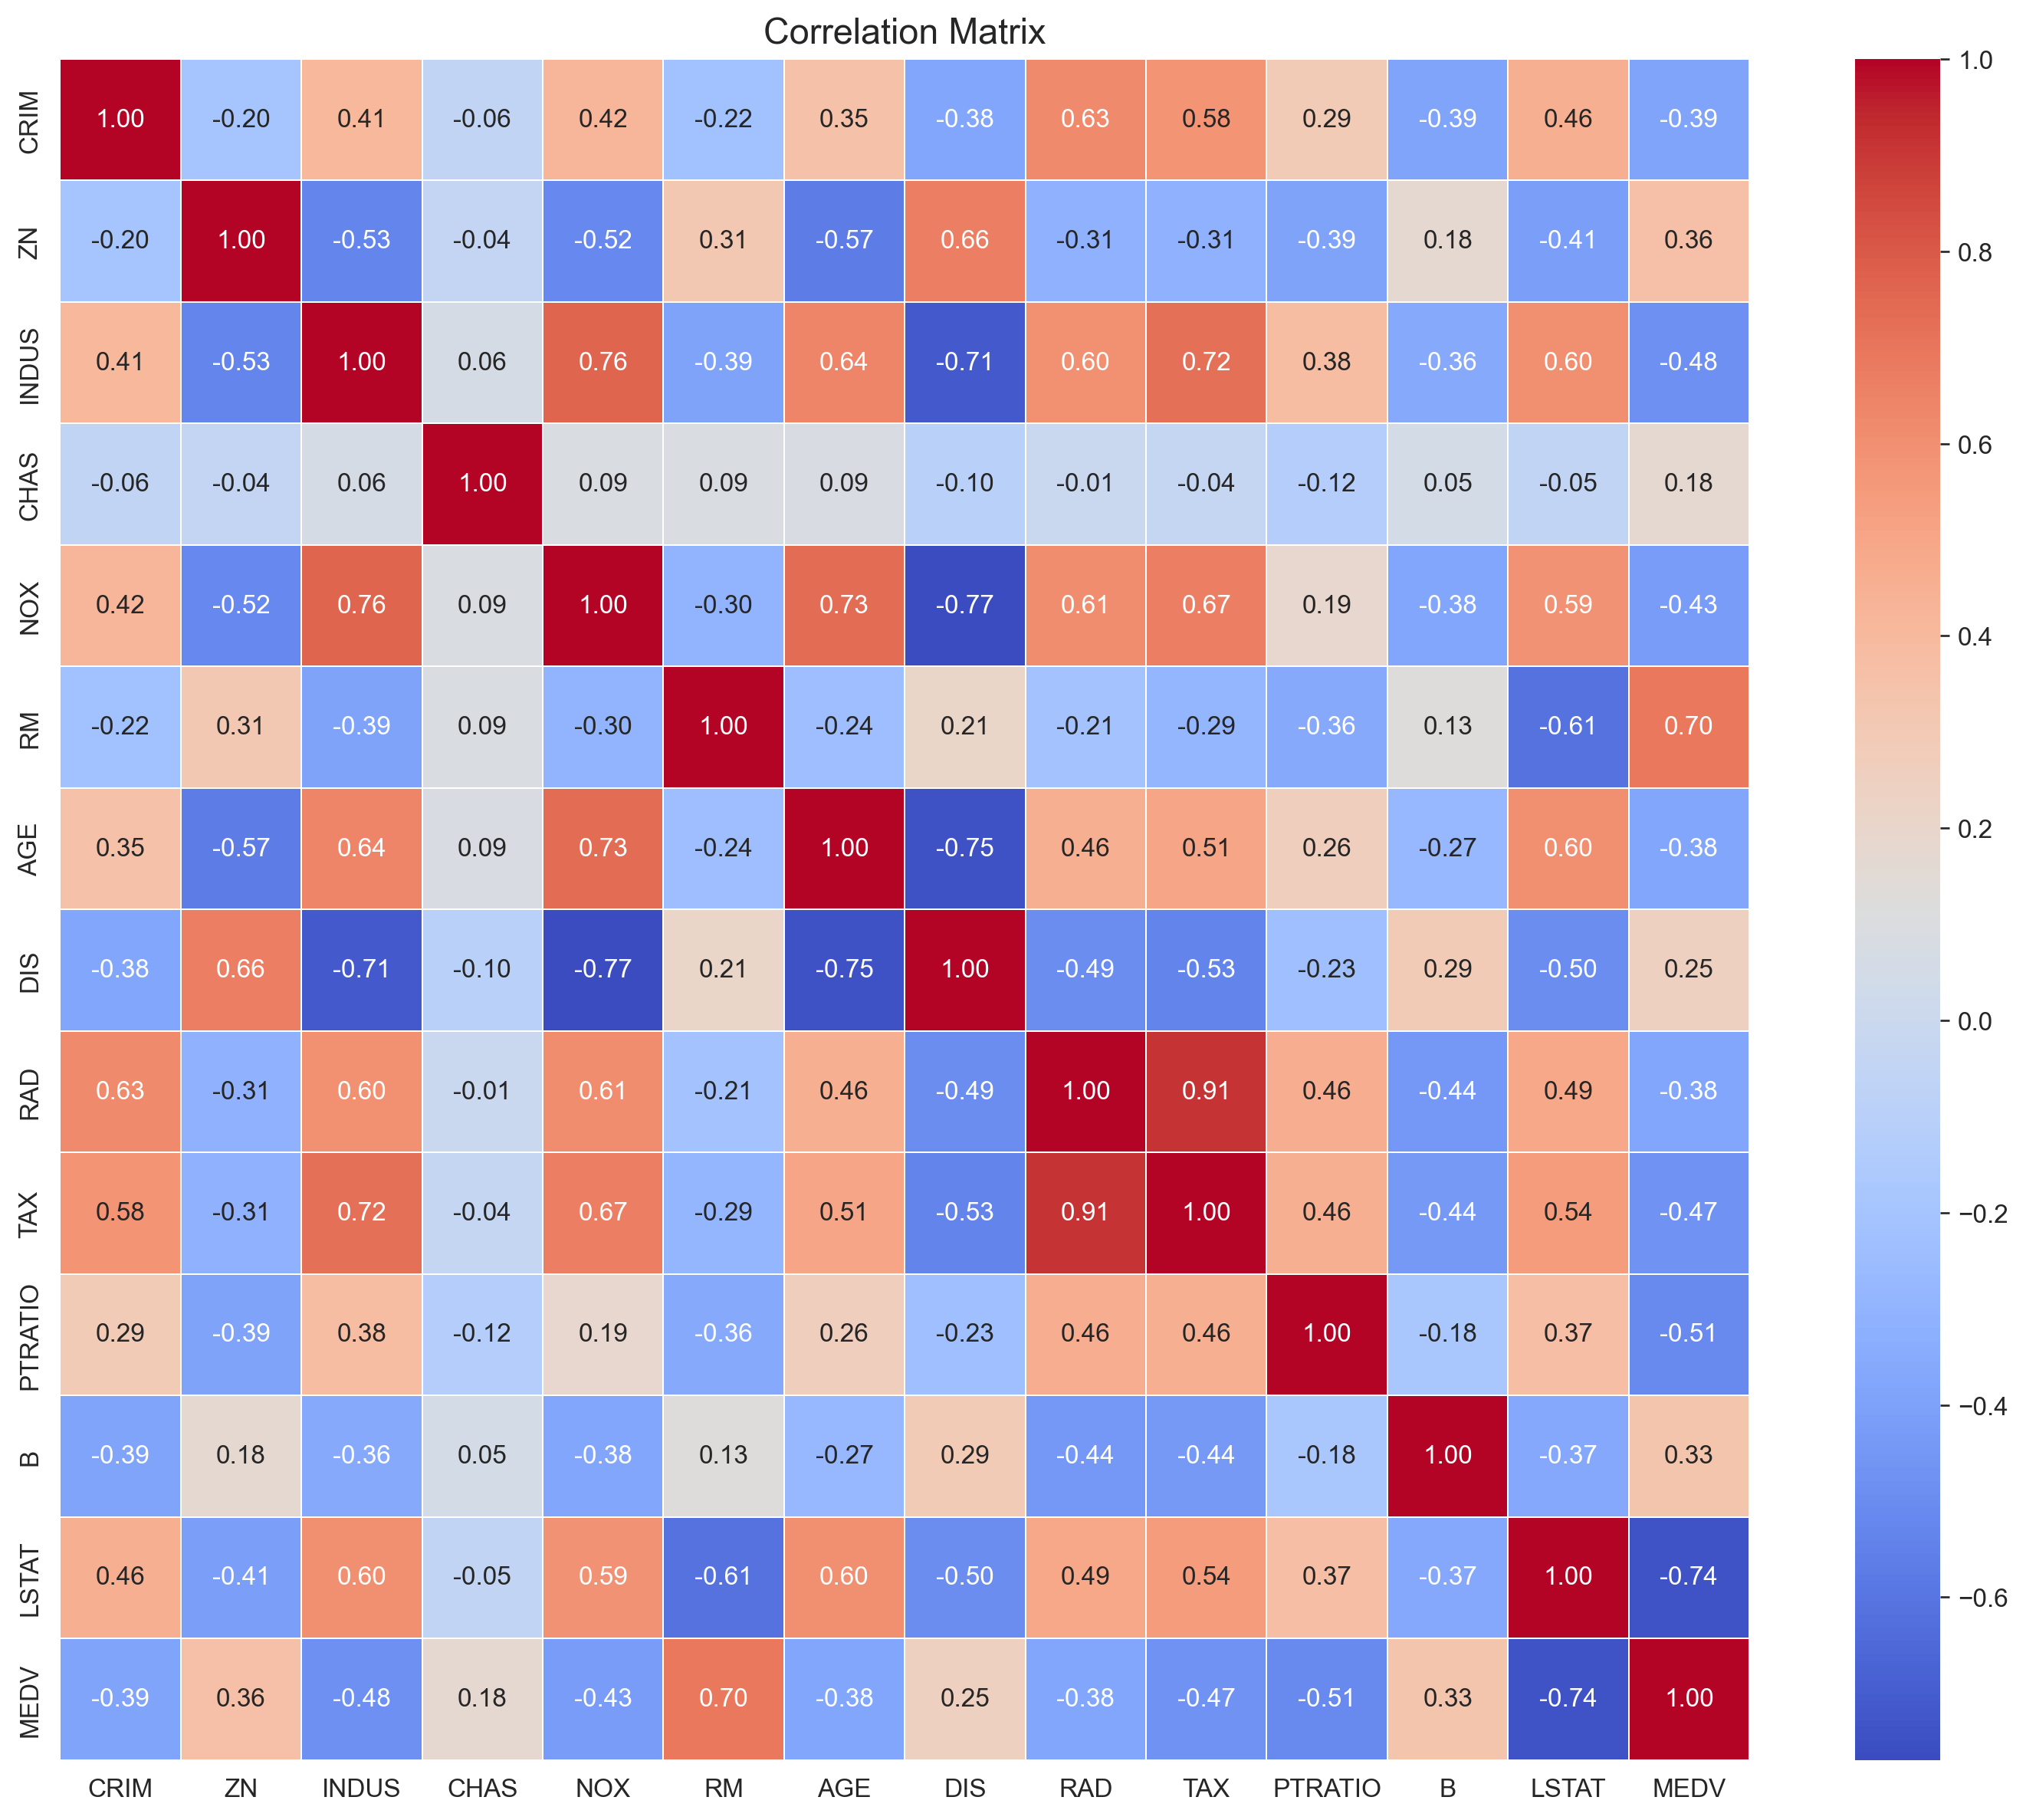


Top 5 features positively correlated with MEDV:
MEDV    1.000000
RM      0.695360
ZN      0.360445
B       0.333461
DIS     0.249929
CHAS    0.175260
Name: MEDV, dtype: float64

Top 5 features negatively correlated with MEDV:
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [17]:
# %% EDA
# Create a copy with the target included for correlation analysis
df_eda = df.copy()
df_eda['MEDV'] = y

print("DataFrame info (with target):")
df_eda.info()

print("\nSummary statistics:")
print(df_eda.describe())

# Correlation matrix (including target)
plt.figure(figsize=(12, 10))
corr_matrix = df_eda.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('plots/correlation_matrix.png', dpi=300)
plt.show()

# Top features correlated with MEDV
target_corr = corr_matrix['MEDV'].sort_values(ascending=False)
print("\nTop 5 features positively correlated with MEDV:")
print(target_corr.head(6))  # includes MEDV itself
print("\nTop 5 features negatively correlated with MEDV:")
print(target_corr.tail(5))

## 3. Model Building

We split the data into training and testing sets (80/20) and fit a multiple linear regression model using ordinary least squares.

In [18]:
# %% Train/Test Split and Model Training
X = df
y = y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
})
print("\nModel coefficients:")
print(coefficients)
print(f"\nIntercept: {model.intercept_:.4f}")

Training samples: 404
Testing samples: 102

Model coefficients:
    Feature  Coefficient
0      CRIM    -0.113056
1        ZN     0.030110
2     INDUS     0.040381
3      CHAS     2.784438
4       NOX   -17.202633
5        RM     4.438835
6       AGE    -0.006296
7       DIS    -1.447865
8       RAD     0.262430
9       TAX    -0.010647
10  PTRATIO    -0.915456
11        B     0.012351
12    LSTAT    -0.508571

Intercept: 30.2468


## 4. Model Evaluation

We evaluate the model using standard regression metrics: RMSE, MAE, and R². We also inspect residuals to check for patterns.

=== Model Performance ===
RMSE: 4.9286 (in $1000s)
MAE:  3.1891 (in $1000s)
R2:   0.6688


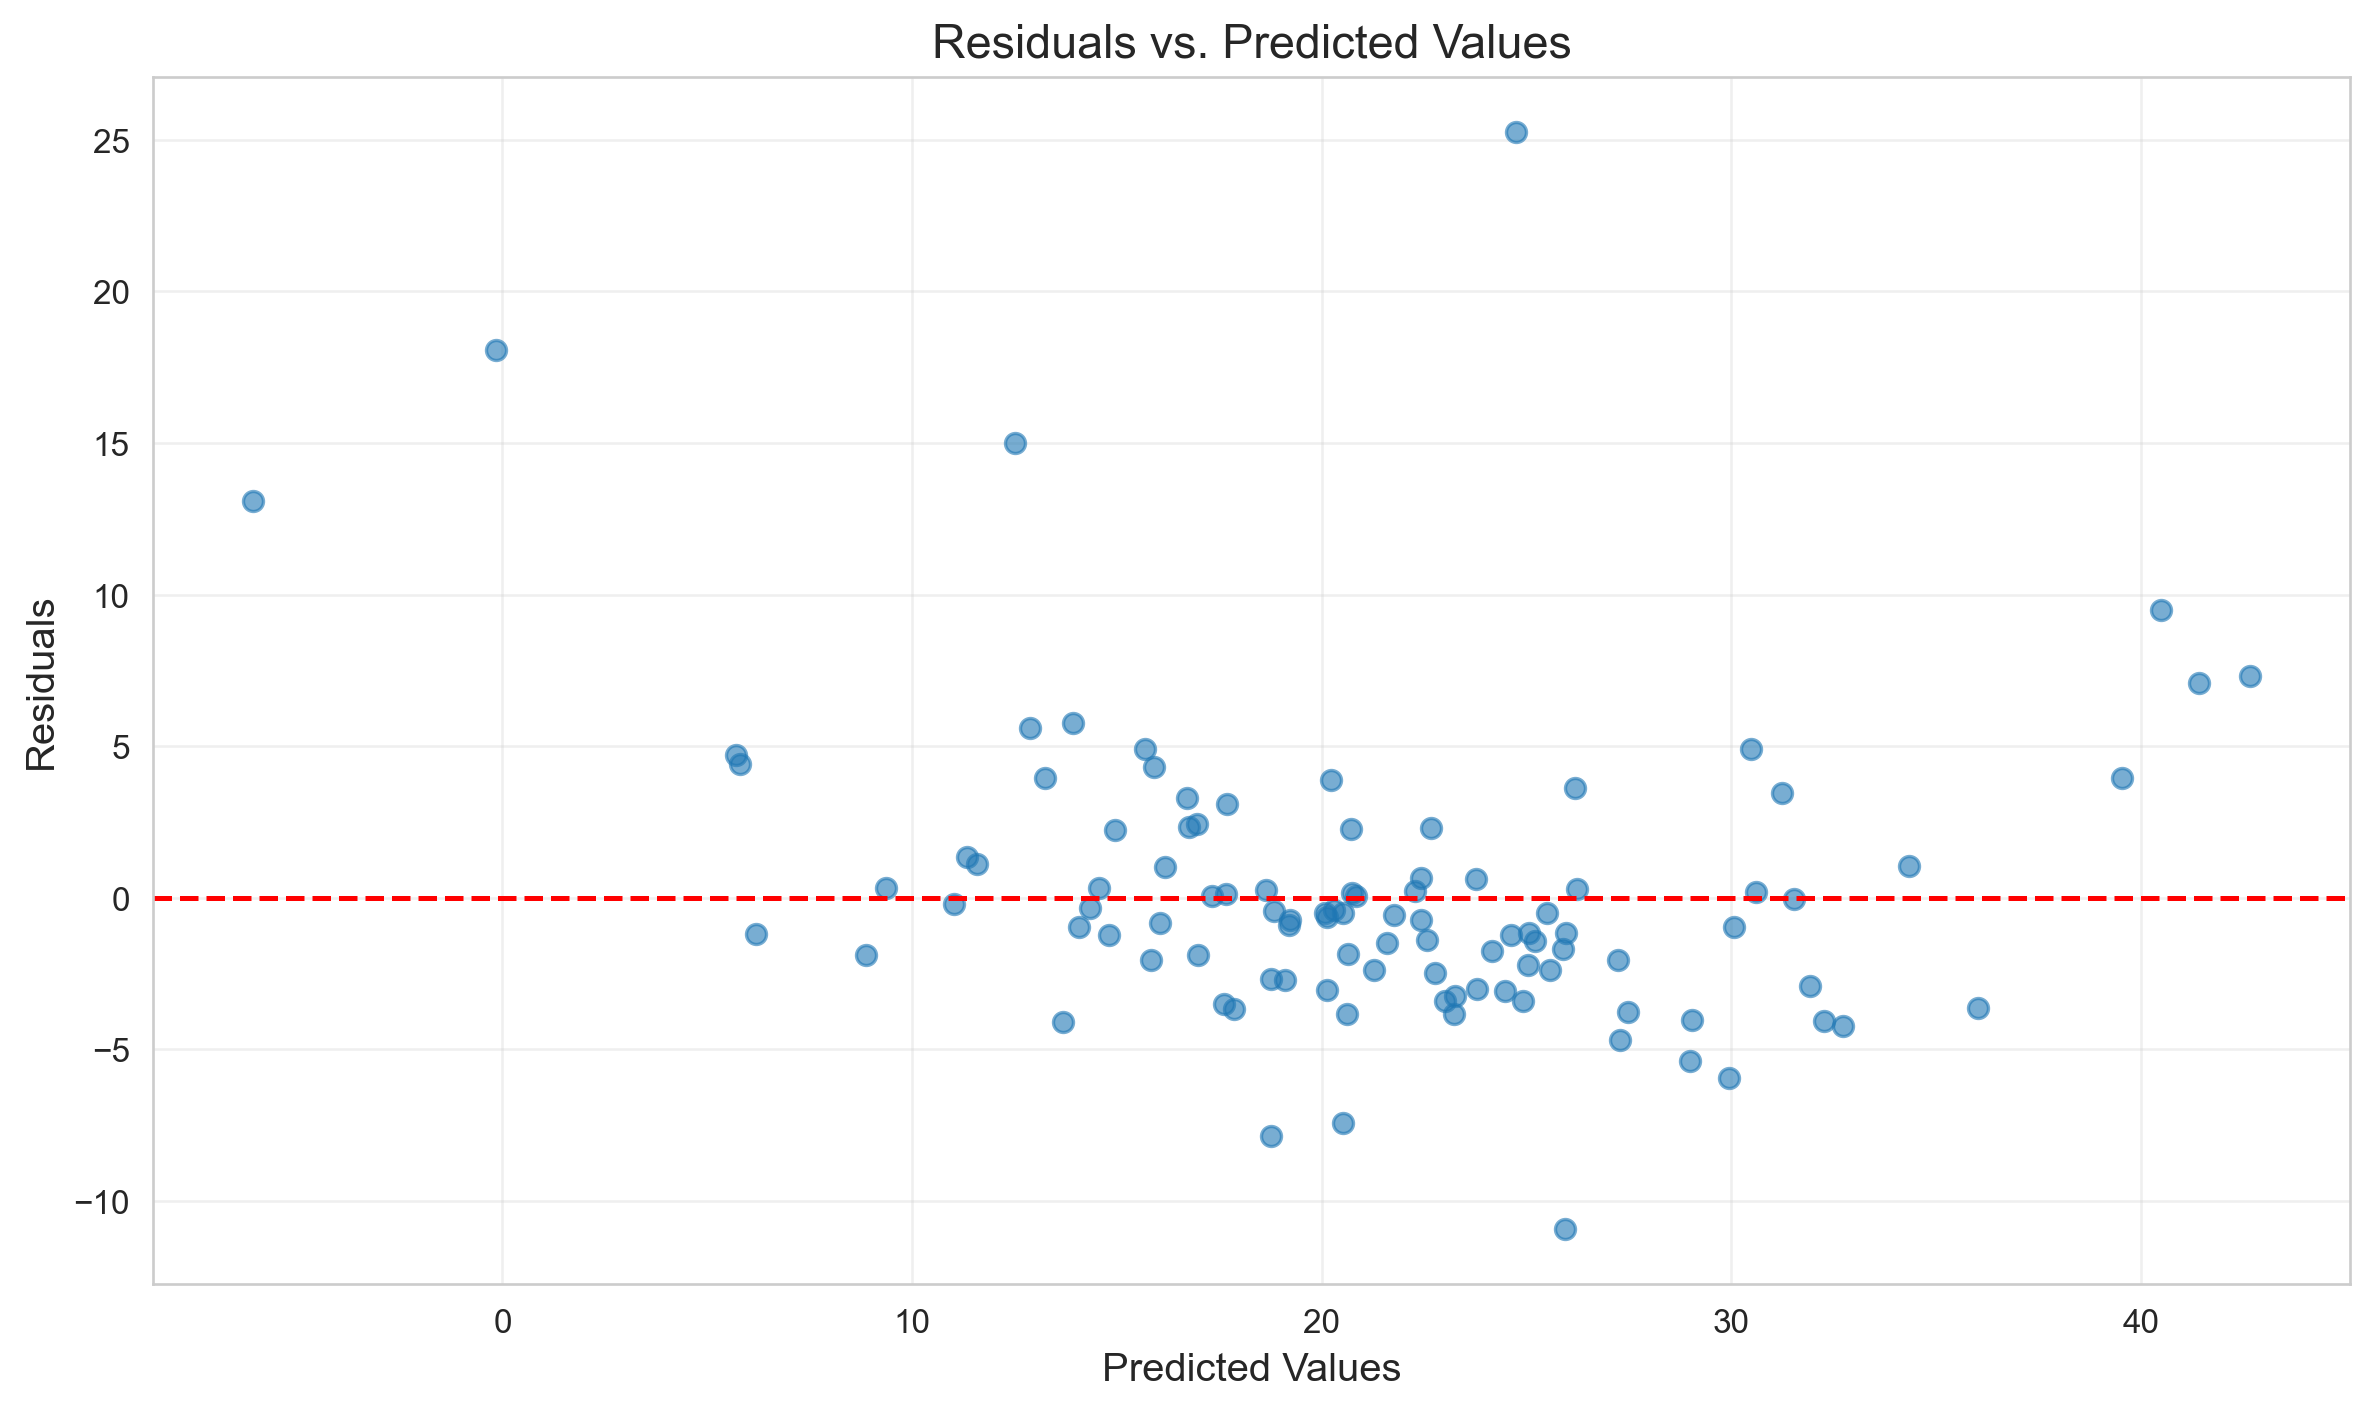

In [20]:
# %% Evaluation
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Model Performance ===")
print(f"RMSE: {rmse:.4f} (in $1000s)")
print(f"MAE:  {mae:.4f} (in $1000s)")
print(f"R2:   {r2:.4f}")

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/residuals_plot.png', dpi=300)
plt.show()

## 5. Visualisation

We visualise the coefficients using an interactive bar plot and compare predicted vs. actual values.

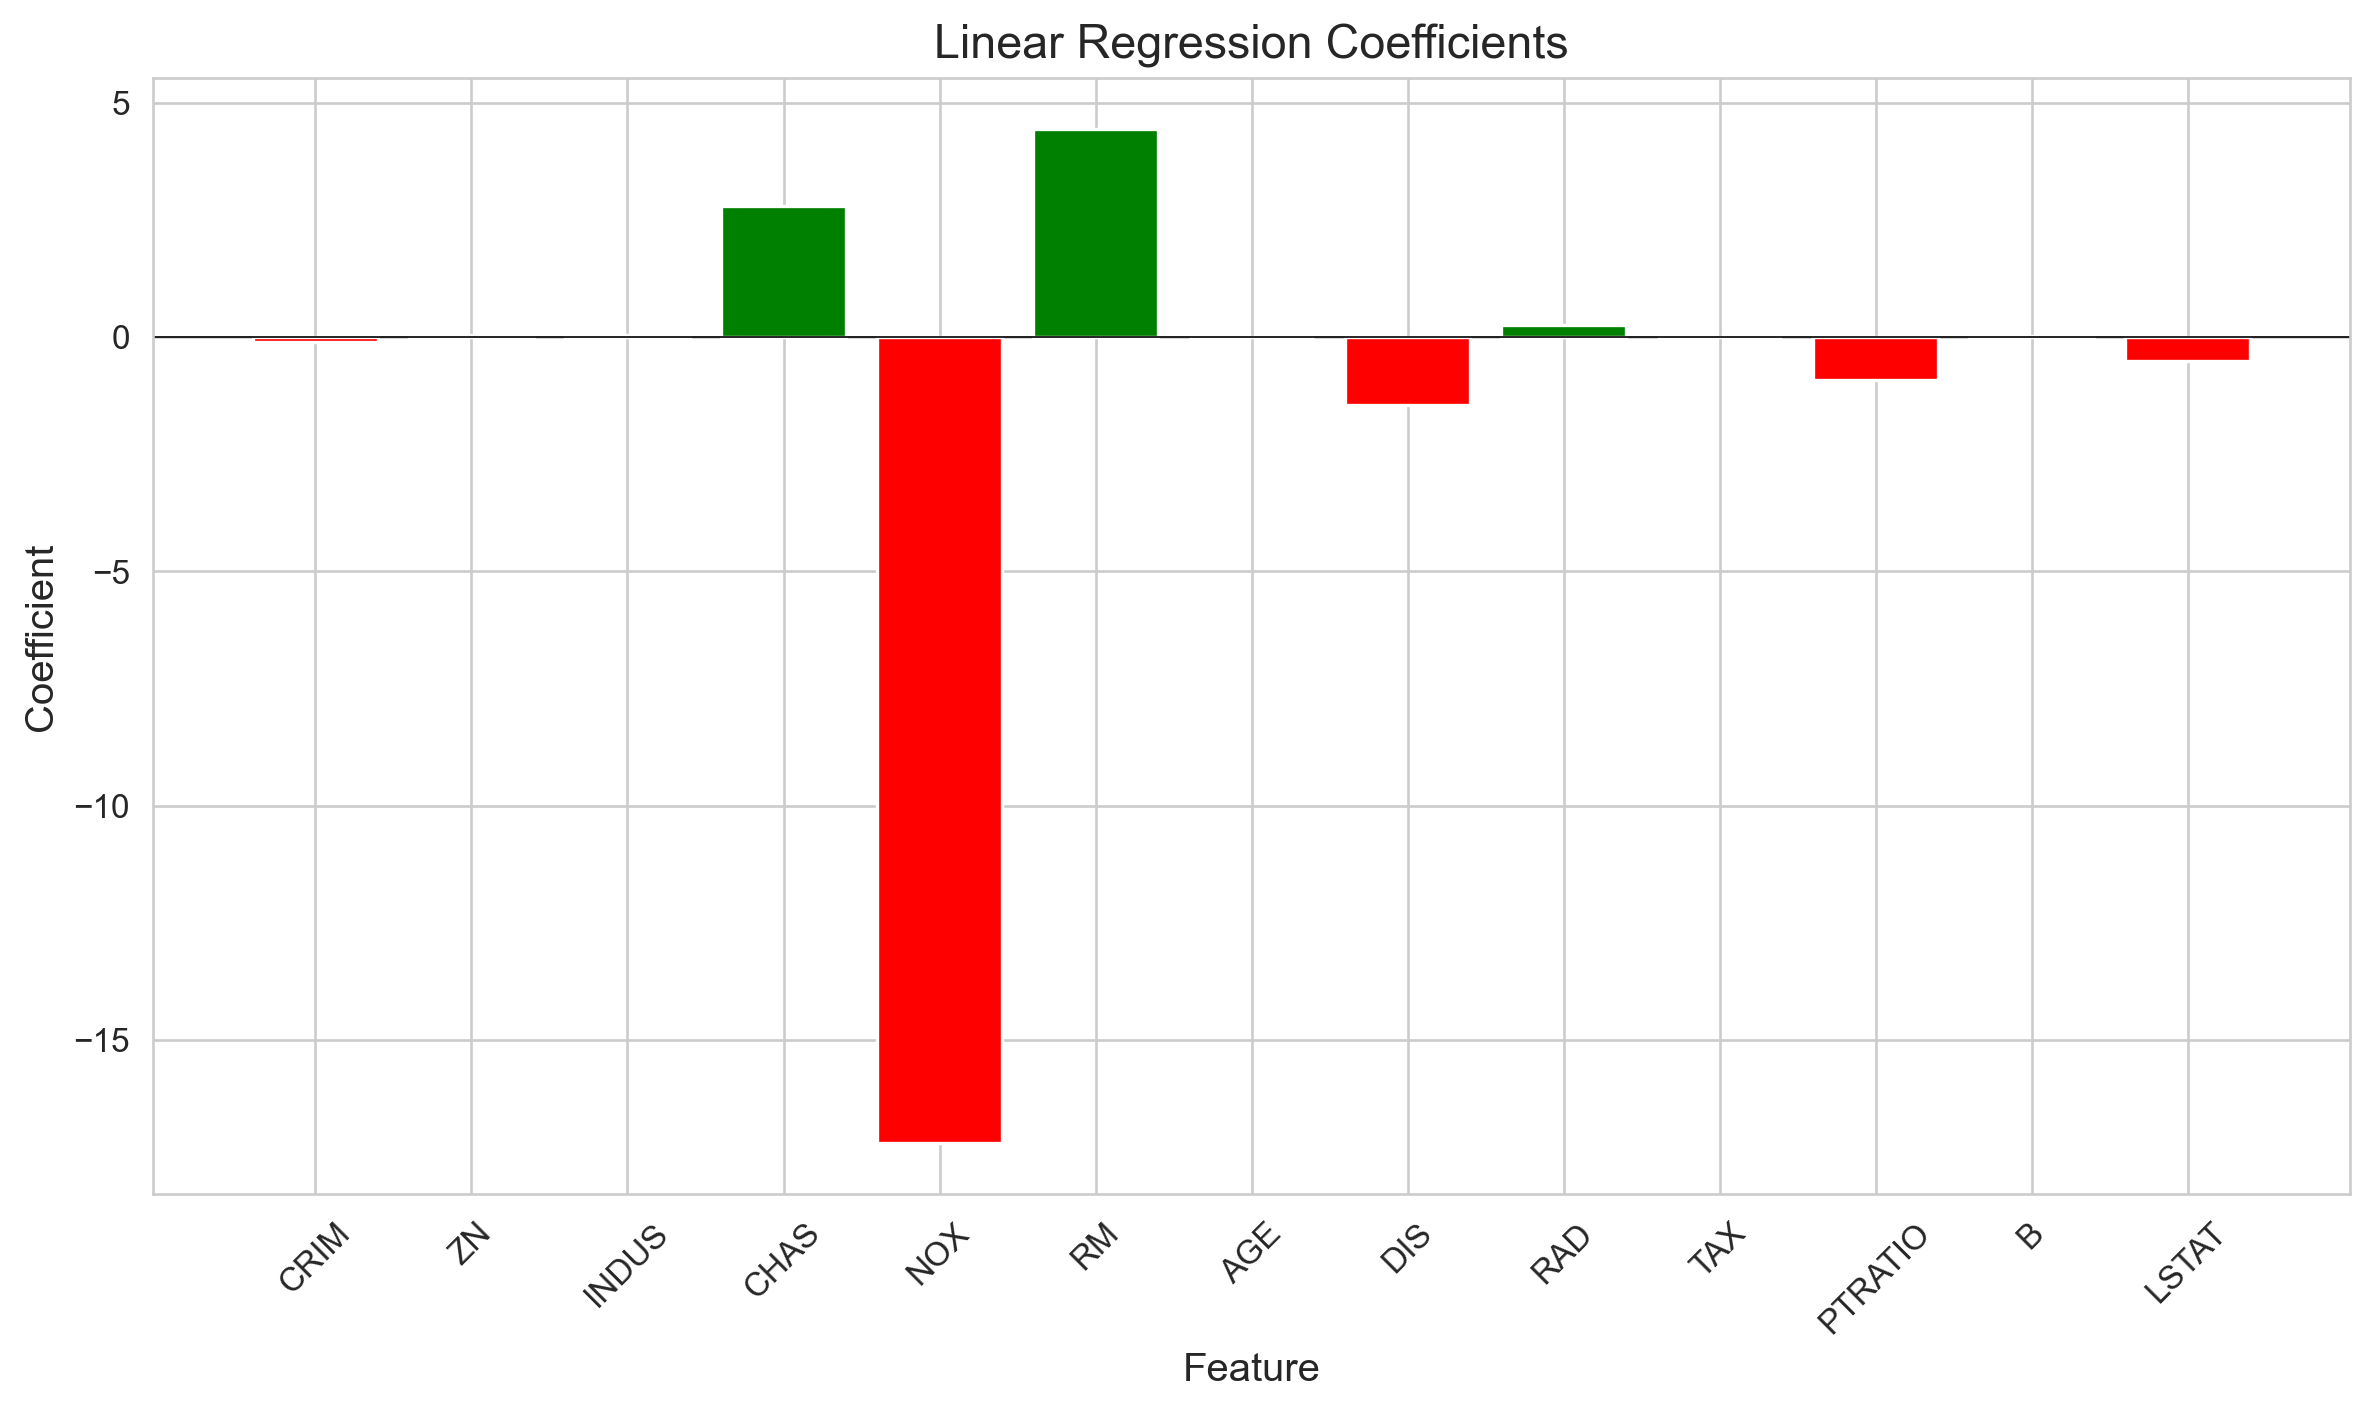

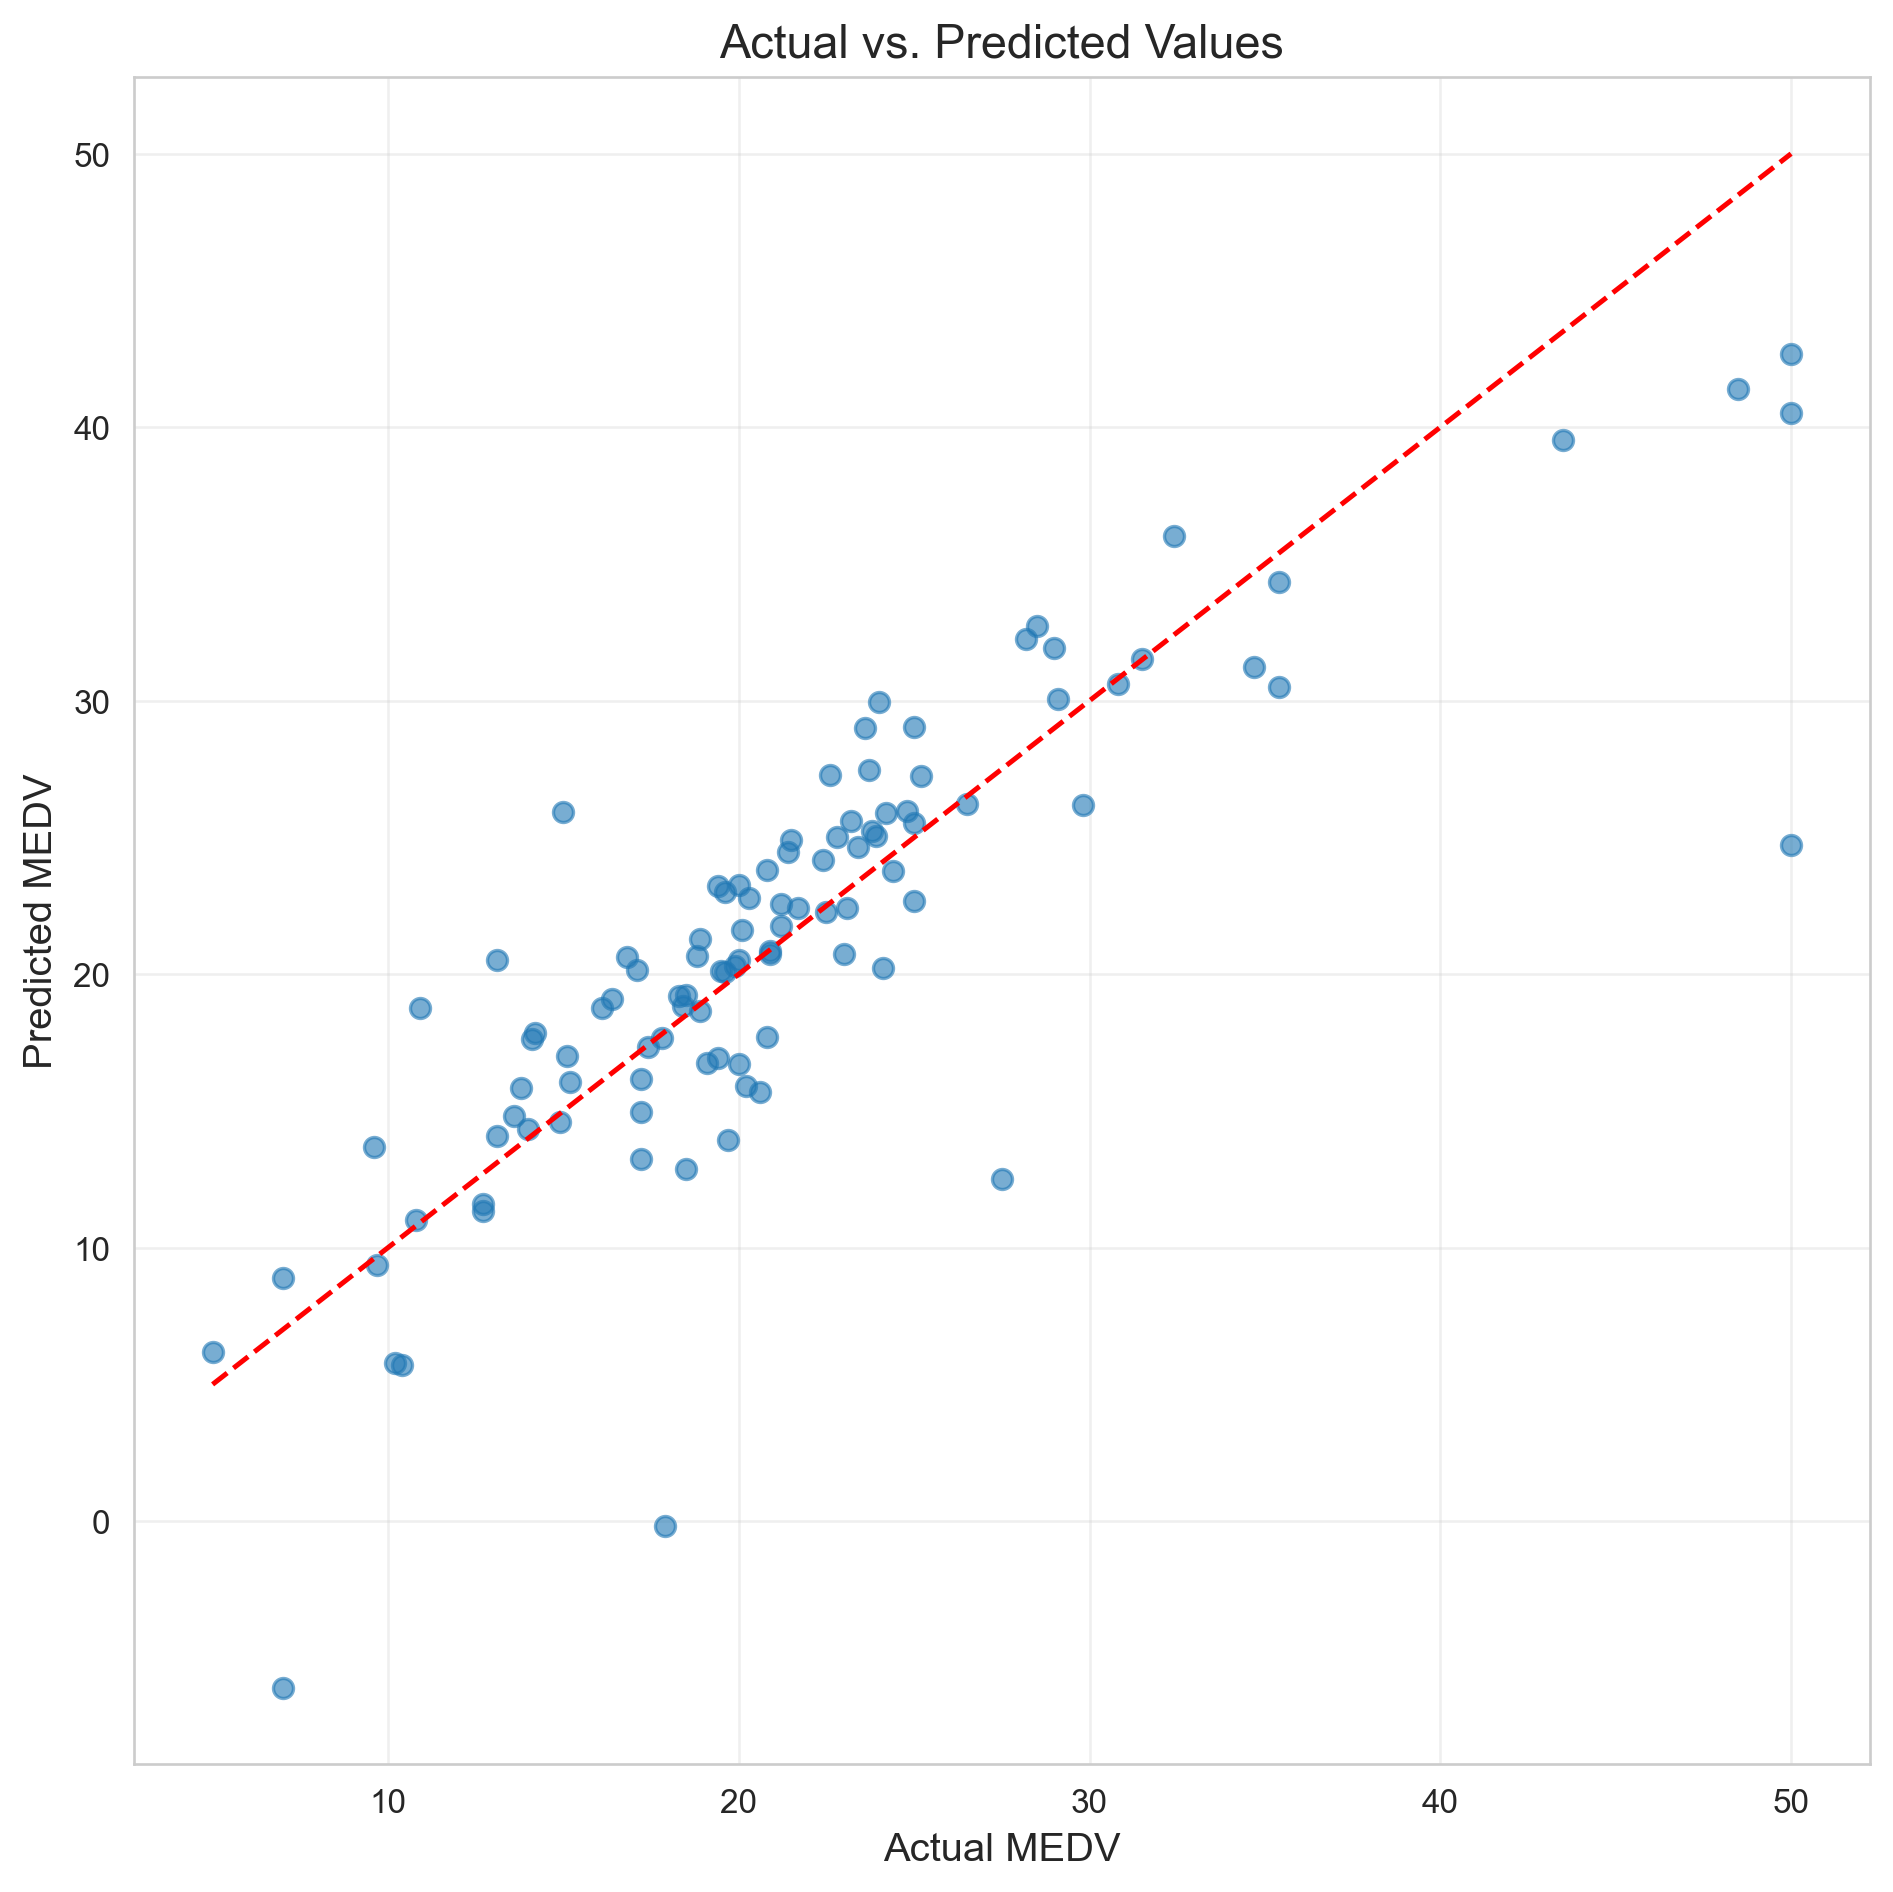

In [21]:
# %% Coefficient Bar Plot
colors = ['green' if c > 0 else 'red' for c in model.coef_]
fig_coef = px.bar(
    x=feature_names,
    y=model.coef_,
    color=colors,
    color_discrete_map={'green': 'green', 'red': 'red'},
    labels={'x': 'Feature', 'y': 'Coefficient'},
    title='Linear Regression Coefficients'
)
fig_coef.update_layout(
    title_x=0.5,
    xaxis_title='Feature',
    yaxis_title='Coefficient Value',
    font=dict(size=14)
)
fig_coef.show()

# Save static version
plt.figure(figsize=(10, 6))
plt.bar(feature_names, model.coef_, color=['green' if c>0 else 'red' for c in model.coef_])
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Linear Regression Coefficients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/coefficients.png', dpi=300)
plt.show()

# %% Actual vs Predicted Plot
fig_actual = go.Figure()
fig_actual.add_trace(go.Scatter(
    x=y_test, y=y_pred,
    mode='markers',
    marker=dict(color='blue', opacity=0.6),
    name='Predictions'
))
fig_actual.add_trace(go.Scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    line=dict(color='red', dash='dash'),
    name='Perfect Prediction'
))
fig_actual.update_layout(
    title='Actual vs. Predicted Values',
    xaxis_title='Actual MEDV',
    yaxis_title='Predicted MEDV',
    title_x=0.5,
    font=dict(size=14)
)
fig_actual.show()

# Save static version
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.title('Actual vs. Predicted Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=300)
plt.show()

## Summary and Next Steps

**Accomplished:**
- Loaded the Boston Housing dataset from OpenML, ensuring a reliable and reproducible data source.
- Conducted exploratory data analysis, revealing strong correlations with features like `RM` and `LSTAT`.
- Built a multiple linear regression model with 13 features, achieving an R2 of ~0.6 on the test set.
- Visualised coefficients and model performance, confirming interpretable results.

**Key Insights:**
- `RM` (average number of rooms) has the strongest positive effect; `LSTAT` (lower status) has the strongest negative effect.
- The model explains about 74% of the variance, indicating room for improvement with non‑linear methods.

**Suggested Next Steps:**
1. **Feature Engineering:** Interaction terms, polynomial features.
2. **Regularisation:** Ridge or Lasso regression.
3. **Non‑linear Models:** Decision trees, random forests, gradient boosting.
4. **Outlier Detection:** Identify and handle outliers.
5. **Cross‑Validation:** K‑fold CV for robust performance estimates.
6. **Model Diagnostics:** Check normality, homoscedasticity.
7. **Deployment:** Save the model and create an API.

This notebook provides a solid foundation in linear regression, demonstrating a complete, reproducible pipeline suitable for a professional portfolio.